# hw3: Обучение без учителя

*Спасибо ещё одному великому курсу mlcourse.ai и авторам: Ольга Дайховская (@aiho в Slack ODS), Юрий Кашницкий (@yorko в Slack ODS).*

### О задании

В этом задании мы разберемся с тем, как работают методы снижения размерности и кластеризации данных. Заодно еще раз попрактикуемся в
задаче классификации.

Мы будем работать с набором данных [Samsung Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones). Данные поступают с акселерометров и гироскопов мобильных телефонов Samsung Galaxy S3 (подробнее про признаки – по ссылке на UCI выше), также известен вид активности человека с телефоном в кармане – ходил ли он, стоял, лежал, сидел или шел вверх/вниз по лестнице.

Вначале мы представим, что вид активности нам неизвестнен, и попробуем кластеризовать людей чисто на основе имеющихся признаков. Затем решим задачу определения вида физической активности именно как задачу классификации.

**Заполните код в клетках (где написано "Ваш код здесь") и ответьте на вопросы, выделив ответ полужирным** (``` **выделить двойными звёздочками** ```).

### Оценивание и штрафы
Вам необходимо ответить на 10 вопросов и выполнить 2 задания. Каждое из заданий и вопросов имеет определенную «стоимость» (указана в скобках). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw3-unsupervised.ipynb``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце "hw3" в строке со своей фамилией о том, что вы выполнили работу и оставить ссылку на ноутбук.


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm_notebook

%matplotlib inline
from matplotlib import pyplot as plt

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.family'] = 'DejaVu Sans'

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 17

In [70]:
# Пути к файлам с учетом того, что они в той же папке,
# что и запускаемый файл (т.к. выполнялось в google colab)
X_train = np.loadtxt("X_train.txt")
y_train = np.loadtxt("y_train.txt").astype(int)

X_test = np.loadtxt("X_test.txt")
y_test = np.loadtxt("y_test.txt").astype(int)

In [10]:
# Проверим размерности
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

Для кластеризации нам не нужен вектор ответов, поэтому будем работать с объединением обучающей и тестовой выборок. Объедините *X_train* с *X_test*, а *y_train* – с *y_test*.

In [11]:
# Объединяем обучающую и тестовую выборки
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

print(X.shape)
print(y.shape)

(10299, 561)
(10299,)


Определим число уникальных значений меток целевого класса.

In [12]:
np.unique(y)

array([1, 2, 3, 4, 5, 6])

In [13]:
n_classes = np.unique(y).size

[Эти метки соответствуют:](https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.names)
- 1 - ходьбе
- 2 - подъему вверх по лестнице
- 3 - спуску по лестнице
- 4 - сидению
- 5 - стоянию
- 6 - лежанию

*уж простите, если звучание этих существительных кажется корявым :)*

Отмасштабируйте выборку с помощью `StandardScaler` с параметрами по умолчанию.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Среднее после масштабирования (должно быть ~0):", X_scaled.mean(axis=0)[:5])
print("Стандартное отклонение (должно быть 1):", X_scaled.std(axis=0)[:5])

Среднее после масштабирования (должно быть ~0): [ 5.52841263e-15 -1.38651383e-15 -5.28337448e-15 -2.21336365e-15
  4.63827227e-16]
Стандартное отклонение (должно быть 1): [1. 1. 1. 1. 1.]


Понижаем размерность с помощью PCA, оставляя столько компонент, сколько нужно для того, чтобы объяснить как минимум 90% дисперсии исходных (отмасштабированных) данных. Используйте отмасштабированную выборку и зафиксируйте random_state (константа RANDOM_STATE).

In [15]:
pca = PCA(n_components=0.9, random_state=RANDOM_STATE)

X_pca = pca.fit_transform(X_scaled)

print("Количество компонент после PCA:", X_pca.shape[1])

Количество компонент после PCA: 65


**Вопрос 1:** (1 балл)

Какое минимальное число главных компонент нужно выделить, чтобы объяснить 90% дисперсии исходных (отмасштабированных) данных?

**Варианты:**
- 56
- **65 (верный ответ)**
- 66
- 193

**Ответ: 2 вариант**

In [18]:
#65, как было получено выше
print("Количество компонент после PCA:", X_pca.shape[1])

Количество компонент после PCA: 65


**Вопрос 2:** (0.5 баллов)

Сколько процентов дисперсии приходится на первую главную компоненту? Округлите до целых процентов.

**Варианты:**
- 45
- **51 (верный ответ)**
- 56
- 61

**Ответ: 2 вариант**

In [20]:
first_pc_variance = pca.explained_variance_ratio_[0] * 100
print("Первая компонента объясняет примерно:", round(first_pc_variance), "% дисперсии")

Первая компонента объясняет примерно: 51 % дисперсии


Визуализируйте данные в проекции на первые две главные компоненты.

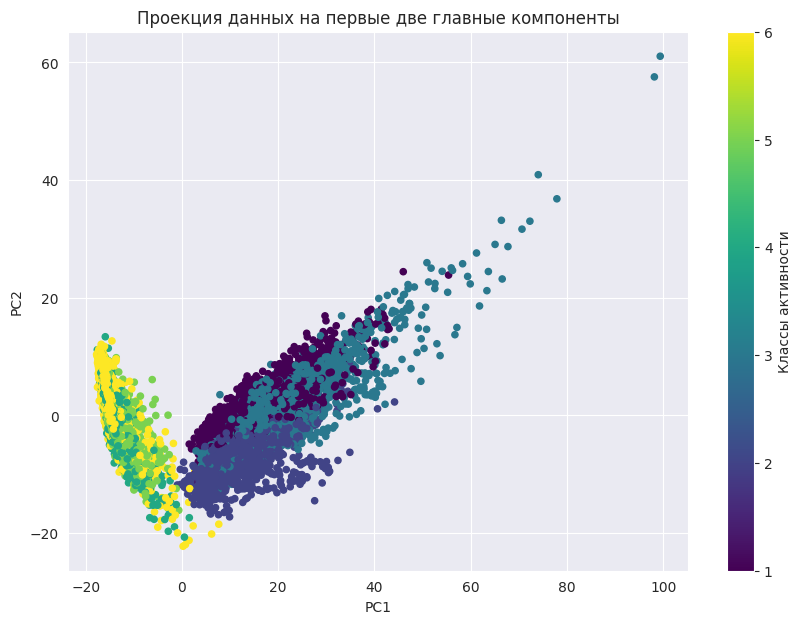

In [26]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=20, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Проекция данных на первые две главные компоненты')
plt.colorbar(label='Классы активности')
plt.show()

**Вопрос 3:** (0.5 баллов)

Если все получилось правильно, Вы увидите сколько-то кластеров, почти идеально отделенных друг от друга. Какие виды активности входят в эти кластеры?<br>

**Ответ:**
- 1 кластер: все 6 активностей
- **2 кластера: (ходьба, подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание) (верный ответ)**
- 3 кластера: (ходьба), (подъем вверх по лестнице, спуск по лестнице) и (сидение, стояние, лежание)
- 6 кластеров

**Ответ: 2 вариант**

------------------------------

In [25]:
# Собственная реализация KMeans
class MyKMeans:
    def __init__(self, n_clusters=6, n_init=100, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.n_init = n_init
        self.max_iter = max_iter
        self.random_state = random_state
        self.cluster_centers_ = None
        self.labels_ = None
        self.inertia_ = None

    def _initialize_centroids(self, X, rng):
        indices = rng.choice(X.shape[0], self.n_clusters, replace=False)
        return X[indices].copy()

    def _compute_distances(self, X, centroids):
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i, centroid in enumerate(centroids):
            distances[:, i] = np.sqrt(np.sum((X - centroid) ** 2, axis=1))
        return distances

    def _update_centroids(self, X, labels):
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                centroids[i] = cluster_points.mean(axis=0)
        return centroids

    def _compute_inertia(self, X, labels, centroids):
        inertia = 0
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - centroids[i]) ** 2)
        return inertia

    def _fit_single(self, X, rng):
        centroids = self._initialize_centroids(X, rng)

        for _ in range(self.max_iter):
            distances = self._compute_distances(X, centroids)
            labels = np.argmin(distances, axis=1)
            new_centroids = self._update_centroids(X, labels)

            if np.allclose(centroids, new_centroids):
                break
            centroids = new_centroids

        inertia = self._compute_inertia(X, labels, centroids)
        return centroids, labels, inertia

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        best_inertia = np.inf

        for _ in range(self.n_init):
            centroids, labels, inertia = self._fit_single(X, rng)
            if inertia < best_inertia:
                best_inertia = inertia
                self.cluster_centers_ = centroids
                self.labels_ = labels
                self.inertia_ = inertia
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

n_clusters = n_classes

# Собственная реализация
kmeans_custom = MyKMeans(n_clusters=n_clusters, n_init=100, random_state=RANDOM_STATE)
labels_custom = kmeans_custom.fit_predict(X_pca)

# Готовая реализация sklearn
kmeans_sklearn = KMeans(n_clusters=n_clusters, n_init=100, random_state=RANDOM_STATE)
labels_sklearn = kmeans_sklearn.fit_predict(X_pca)

print(f"Инерция (собственная реализация): {kmeans_custom.inertia_:.4f}")
print(f"Инерция (sklearn): {kmeans_sklearn.inertia_:.4f}")

Инерция (собственная реализация): 2003454.2019
Инерция (sklearn): 2003454.8999


**Задание 1.** (1 балл)

Сделайте кластеризацию данных методом `KMeans` (собственная имплементация и готовая реализация), обучив модель на данных со сниженной за счет PCA размерностью. В данном случае мы подскажем, что нужно искать именно 6 кластеров, но в общем случае мы не будем знать, сколько кластеров надо искать.

Параметры:

- **n_clusters** = n_classes (число уникальных меток целевого класса)
- **n_init** = 100
- **random_state** = RANDOM_STATE (для воспроизводимости результата)

Остальные параметры со значениями по умолчанию.

Инерция служит хорошим показателем, чтобы сравнить реализации. Она позволяет оценить плотность и качество кластеров и проверить работу своей реализации.

Визуализируйте данные в проекции на первые две главные компоненты. Раскрасьте точки в соответствии с полученными метками кластеров.

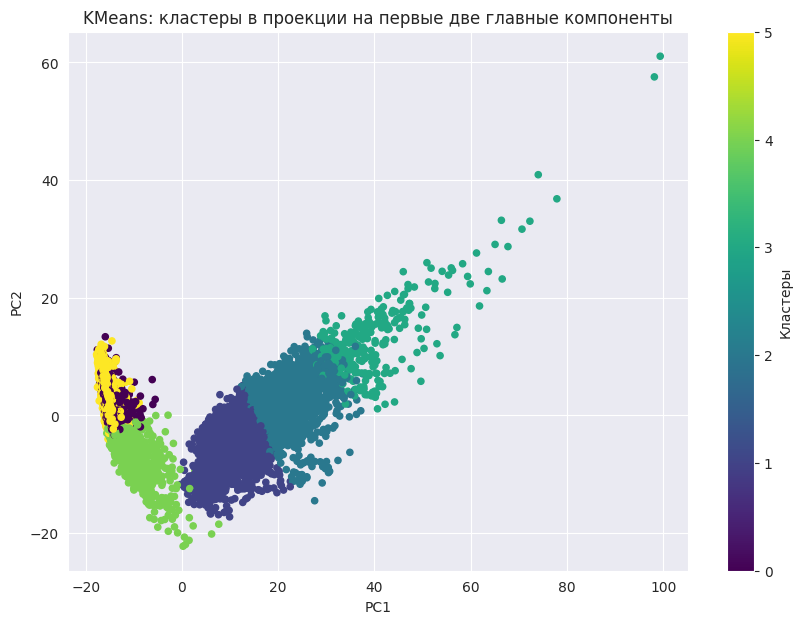

In [32]:
cluster_labels = kmeans.labels_

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    s=20,
    cmap='viridis'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans: кластеры в проекции на первые две главные компоненты')
plt.colorbar(label='Кластеры')
plt.show()

Посмотрите на соответствие между метками кластеров и исходными метками классов и на то, какие виды активностей алгоритм `KMeans` путает.

In [33]:
tab = pd.crosstab(y, cluster_labels, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице',
             'спуск по лестнице', 'сидение', 'стояние', 'лежание', 'все']
tab.columns = ['cluster' + str(i + 1) for i in range(6)] + ['все']
tab

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6,все
ходьба,0,903,741,78,0,0,1722
подъем вверх по лестнице,0,1241,296,5,2,0,1544
спуск по лестнице,0,320,890,196,0,0,1406
сидение,1235,1,0,0,450,91,1777
стояние,1344,0,0,0,562,0,1906
лежание,52,5,0,0,329,1558,1944
все,2631,2470,1927,279,1343,1649,10299


Видим, что каждому классу (т.е. каждой активности) соответствуют несколько кластеров. Давайте посмотрим на максимальную долю объектов в классе, отнесенных к какому-то одному кластеру. Это будет простой метрикой, характеризующей, насколько легко класс отделяется от других при кластеризации.

Пример: если для класса "спуск по лестнице", в котором 1406 объектов,  распределение кластеров такое:
 - кластер 1 – 900
 - кластер 3 – 500
 - кластер 6 – 6,

то такая доля будет 900 / 1406 $\approx$ 0.64.


**Вопрос 4:** (1 балл)

Какой вид активности отделился от остальных лучше всего в терминах простой  метрики, описанной выше?<br>

**Ответ:**
- ходьба
- стояние
- спуск по лестнице
- **перечисленные варианты не подходят (верный ответ)**

Расчеты максимальных долей:

Ходьба: 903/1722 ≈ 0.524
Подъем вверх по лестнице: 1241/1544 ≈ 0.804
Спуск по лестнице: 890/1406 ≈ 0.633
Сидение: 1235/1777 ≈ 0.695
Стояние: 1344/1906 ≈ 0.705
Лежание: 1558/1944 ≈ 0.801

подъема вверх нет, поэтому выбираем 4 вариант

**Ответ: 4 вариант**

Видно, что kMeans не очень хорошо отличает только активности друг от друга. Используйте метод локтя, чтобы выбрать оптимальное количество кластеров. Параметры алгоритма и данные используем те же, что раньше, меняем только `n_clusters`.

/tmp/ipython-input-3785322300.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(range(1, n_classes + 1)):


  0%|          | 0/6 [00:00<?, ?it/s]

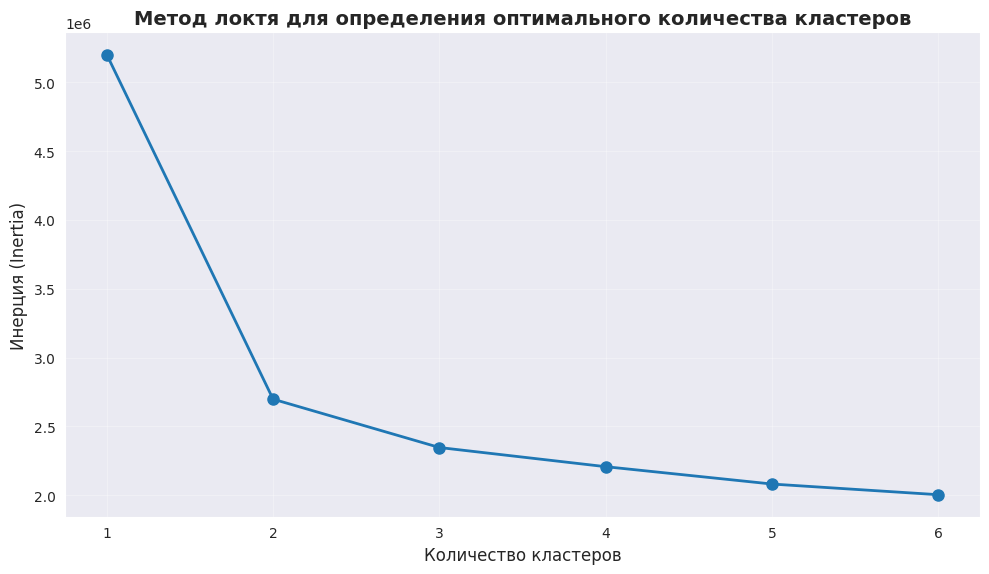

k=1: инерция = 5202757.6816
k=2: инерция = 2697926.7582
k=3: инерция = 2346425.1043
k=4: инерция = 2207131.8190
k=5: инерция = 2080985.1129
k=6: инерция = 2003454.8999


In [36]:
inertia = []
for k in tqdm_notebook(range(1, n_classes + 1)):
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=RANDOM_STATE)
    kmeans.fit(X_pca)
    inertia.append(kmeans. inertia_)

# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_classes + 1), inertia, marker='o', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Инерция (Inertia)', fontsize=12)
plt.title('Метод локтя для определения оптимального количества кластеров', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, n_classes + 1))
plt.tight_layout()
plt.show()

# Вывод значений инерции
for k, inertia_val in enumerate(inertia, start=1):
    print(f"k={k}: инерция = {inertia_val:.4f}")

**Вопрос 5:** (1 балл)

Какое количество кластеров оптимально выбрать, согласно методу локтя?<br>

**Ответ:**
- 1
- **2 (верный ответ)**
- 3
- 4

In [ ]:
2, потому что самое сильное падение там наблюдается

**Ответ: 2 вариант**

------------------------

Попробуем еще один метод кластеризации, который описывался в статье – агломеративную кластеризацию.

In [38]:
ag = AgglomerativeClustering(n_clusters=n_classes,
                             linkage='ward').fit(X_pca)

Посчитайте Adjusted Rand Index (`sklearn.metrics`) для получившегося разбиения на кластеры и для `KMeans` с параметрами из задания к 4 вопросу.

In [41]:
from sklearn.metrics import adjusted_rand_score

labels_ag = ag.fit_predict(X_pca)

# Adjusted Rand Index
ari_kmeans = adjusted_rand_score(y, labels_sklearn)
ari_ag = adjusted_rand_score(y, labels_ag)

print(f"ARI для KMeans: {ari_kmeans:.4f}")
print(f"ARI для Agglomerative Clustering: {ari_ag:.4f}")

ARI для KMeans: 0.4198
ARI для Agglomerative Clustering: 0.4936


**Вопрос 6:** (1 балл)

Отметьте все верные утверждения.<br>

**Варианты:**
- **Согласно ARI, KMeans справился с кластеризацией хуже, чем Agglomerative Clustering**
- **Для ARI не имеет значения какие именно метки присвоены кластерам, имеет значение только разбиение объектов на кластеры**
- **В случае случайного разбиения на кластеры ARI будет близок к нулю**

**Ответ: все верны**

-------------------------------

Можно заметить, что задача не очень хорошо решается именно как задача кластеризации, если выделять несколько кластеров (> 2). Давайте теперь решим задачу классификации, вспомнив, что данные у нас размечены.  

Для классификации используйте метод опорных векторов – класс `sklearn.svm.LinearSVC`. Мы в курсе отдельно не рассматривали этот алгоритм, но он очень известен, почитать про него можно, например, в материалах Евгения Соколова –  [тут](https://github.com/esokolov/ml-course-msu/blob/master/ML16/lecture-notes/Sem11_linear.pdf).

Настройте для `LinearSVC` гиперпараметр `C` с помощью `GridSearchCV`.

- Обучите новый `StandardScaler` на обучающей выборке (со всеми исходными признаками), прмиените масштабирование к тестовой выборке
- В `GridSearchCV` укажите  cv=3.

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

In [63]:
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=svc_params,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_svc = grid_search.best_estimator_

In [64]:
print("Лучшее значение C:", grid_search.best_params_['C'])
print("Лучшее среднее cv-качество:", grid_search.best_score_)

Лучшее значение C: 0.1
Лучшее среднее cv-качество: 0.9379785010699506


**Вопрос 7** (0.5 баллов)

Какое значение гиперпараметра `C` было выбрано лучшим по итогам кросс-валидации?<br>

**Ответ:**
- 0.001
- 0.01
- **0.1 (верный ответ)**
- 1
- 10

**Ответ: 3 вариант**

In [47]:
y_predicted = best_svc.predict(X_test_scaled)

In [48]:
tab = pd.crosstab(y_test, y_predicted, margins=True)
tab.index = ['ходьба', 'подъем вверх по лестнице', 'спуск по лестнице',
             'сидение', 'стояние', 'лежание', 'все']
tab.columns = tab.index
tab

,ходьба,подъем вверх по лестнице,спуск по лестнице,сидение,стояние,лежание,все
ходьба,494,2,0,0,0,0,496
подъем вверх по лестнице,12,459,0,0,0,0,471
спуск по лестнице,2,4,413,1,0,0,420
сидение,0,4,0,426,61,0,491
стояние,0,0,0,15,517,0,532
лежание,0,0,0,0,11,526,537
все,508,469,413,442,589,526,2947


**Вопрос 8:** (0.5 балл)

Какой вид активности SVM определяет хуже всего в терминах точности? Полноты? <br>

**Ответ:**
- по точности – подъем вверх по лестнице, по полноте – лежание
- по точности – лежание, по полноте – сидение
- по точности – ходьба, по полноте – ходьба
- **по точности – сидение, по полноте – стояние (верный ответ)**

**Ответ: 4 вариант**

Наконец, проделайте то же самое, что в 7 вопросе, только добавив PCA.

- Используйте выборки `X_train_scaled` и `X_test_scaled`
- Обучите тот же PCA, что раньше, на отмасшабированной обучающей выборке, примените преобразование к тестовой
- Настройте гиперпараметр `C` на кросс-валидации по обучающей выборке с PCA-преобразованием. Вы заметите, насколько это проходит быстрее, чем раньше.

**Вопрос 9:** (1 балл)

Какова разность между лучшим качеством (долей верных ответов) на кросс-валидации в случае всех 561 исходных признаков и во втором случае, когда применялся метод главных компонент? Округлите до целых процентов.<br>

**Варианты:**
- Качество одинаковое
- 2%
- **4% (верный ответ)**
- 10%
- 20%


**Ответ: 3 вариант**

In [65]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.9, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

svc = LinearSVC(random_state=RANDOM_STATE)
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10]}

pca_search = GridSearchCV(
    estimator=svc,
    param_grid=svc_params,
    cv=3,
    verbose=1,
    scoring='accuracy',
    n_jobs=-1
)

pca_search.fit(X_train_pca, y_train)

print(f"Лучший C с PCA: {pca_search.best_params_['C']}")
print(f"Лучший CV score с PCA: {pca_search.best_score_:.3f}")

percent = (grid_search.best_score_ - pca_search.best_score_) * 100
print(f"Процентная разница: {percent}%")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Лучший C с PCA: 0.1
Лучший CV score с PCA: 0.898
Процентная разница: 3.958023519485321%


**Вопрос 10:** (1 балл)

Выберите все верные утверждения:

**Варианты:**
- Метод главных компонент в данном случае позволил уменьшить время обучения модели, при этом качество (доля верных ответов на кросс-валидации) очень пострадало, более чем на 10%
- **PCA можно использовать для визуализации данных, однако для этой задачи есть и лучше подходящие методы, например, tSNE. Зато PCA имеет меньшую вычислительную сложность**
- **PCA строит линейные комбинации исходных признаков, и в некоторых задачах они могут плохо интерпретироваться человеком**

**Ответ: 2 и 3 варианты**

**Задание 2.** (1 балл)

Попробуйте использовать DBSCAN в качестве алгоритма кластеризации и метод понижения размерности tSNE.

Применение t-SNE...
Размерность после t-SNE:  (7352, 2)

Применение DBSCAN...
Количество кластеров: 333
Количество шумовых точек:  3696


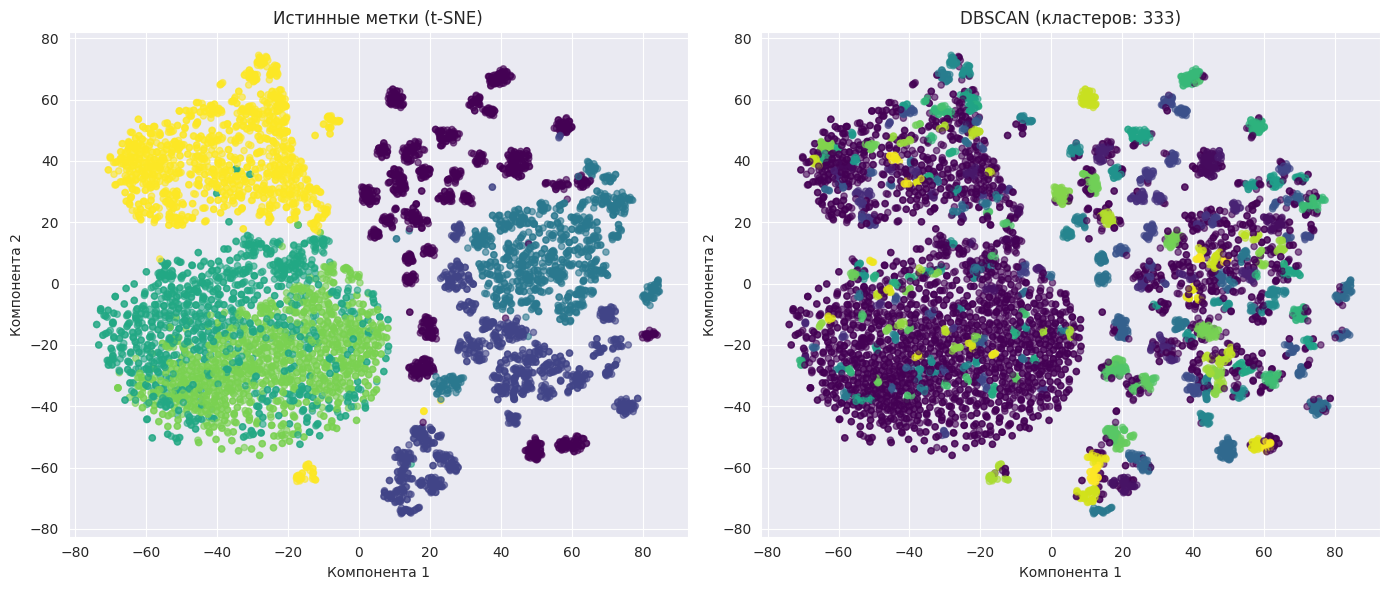

In [67]:
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

print("Применение t-SNE...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_train_scaled)

print(f"Размерность после t-SNE:  {X_tsne.shape}")

print("\nПрименение DBSCAN...")
dbscan = DBSCAN(eps=1.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_tsne)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"Количество кластеров: {n_clusters}")
print(f"Количество шумовых точек:  {n_noise}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=20)
axes[0].set_title('Истинные метки (t-SNE)')
axes[0].set_xlabel('Компонента 1')
axes[0].set_ylabel('Компонента 2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_dbscan, cmap='viridis', alpha=0.6, s=20)
axes[1].set_title(f'DBSCAN (кластеров: {n_clusters})')
axes[1].set_xlabel('Компонента 1')
axes[1].set_ylabel('Компонента 2')

plt.tight_layout()
plt.show()